# 💰 Modelo de Propensión y Optimización por Valor Esperado (EV)

**Hackathon AI Telecom Challenge 2026 — Desafío 02 (Personalización Comercial Inteligente)**  
**Área de Negocio:** Crecimiento, Ventas y Fidelización B2C (Movistar Total + NBO)

---

## 1. Contexto y Diagnóstico del Desafío

En el diagnóstico auditado de modelado (`docs/diagnostico_modelos.md`), se identificaron dos causas fundamentales por las cuales los modelos predictivos estándar no lograban superar económicamente a las reglas de negocio simples:

1. **Desalineación del Objetivo Comercial:**  
   Los modelos tradicionales de clasificación optimizan $\hat{P}(\text{acepta})$. Sin embargo, en el catálogo de ofertas existe una asimetría estructural de precios:
   - **Movistar Total (MT):** Ticket promedio $\approx$ S/ 190, tasa base $\approx$ 69.7% $\rightarrow$ **Valor Esperado:** S/ 132.43.
   - **Planes no-MT (hogar, móvil, upgrade, paquetes):** Tickets S/ 20 – S/ 113, tasas $\approx$ 34% $\rightarrow$ **Valor Esperado:** S/ 7.00 – S/ 38.00.  
   Un modelo que ordena por probabilidad pura reparte ofertas de bajo ticket porque no discrimina entre las ofertas no-MT. La regla heurística `B2_regla_mt_primero`, al forzar MT, capturaba más ingreso de manera accidental.

2. **Corrección Metodológica del Dataset (Exclusión de Rebates):**  
   Las 47,572 filas con `es_rebate = True` son 100% rechazos (fuga estructural). Los benchmarks anteriores que incluían rebates diluían artificialmente la tasa de aceptación global a 37.47%. El universo real de ofertas primarias contiene **207,046 contactos** con una tasa de aceptación del **46.08%**.

---

## 2. Objetivo de este Notebook

1. **Entrenar y calibrar** modelos de propensión (Regresión Logística y LightGBM) en el universo limpio de ofertas primarias (`es_rebate == False` y resultado resuelto).
2. **Implementar la función de decisión de Valor Esperado:**
   $$\text{EV} = \hat{P}(\text{aceptada} \mid \text{cliente}, \text{oferta}, \text{canal}) \times \text{precio\_mensual}$$
3. **Comparar sistemáticamente** el Valor Esperado frente a una escalera de 5 benchmarks:
   - `B0_azar`: Asignación aleatoria.
   - `B1_popularidad`: Oferta con mayor tasa global.
   - `B2_regla_negocio`: Heurística comercial (Movistar Total primero para elegibles).
   - `B3_popularidad_celda`: Tabla empírica de frecuencias `(oferta, canal)`.
   - `M1_probabilidad_pura`: Ranking ML por $\hat{P}(\text{acepta})$.
   - `M2_valor_esperado_EV`: Ranking ML por $\text{EV} = \hat{P} \times \text{precio}$.
4. **Evaluar el impacto financiero:** Curvas de ingreso mensual capturado (PEN@K), aceptaciones capturadas, lift y métricas de negocio.
5. **Persistir reportes y métricas** en `data/processed/modelo_valor_esperado/`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
DIR_SALIDA = Path("../data/processed/modelo_valor_esperado")
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

print("Entorno configurado. Directorio de salida:", DIR_SALIDA.resolve())

Entorno configurado. Directorio de salida: D:\hacka_movistar\data\processed\modelo_valor_esperado


## 3. Carga y Curaduría de Datos

Cargamos los tres datasets fuente inmutables de `data/raw/` y aplicamos el filtro metodológico correcto:
- Exclusión de `es_rebate == True` (ofertas de rebate con 100% rechazo).
- Exclusión de `resultado == 'pendiente'` (sin contacto efectivo).
- Dataset resultante: 207,046 observaciones con resultado binario (`aceptada` / `rechazada`).

In [2]:
# 1. Carga de datasets
df_clientes = pd.read_csv("../data/raw/dataset_clientes.csv")
df_catalogo = pd.read_csv("../data/raw/catalogo_ofertas_entrega.csv")
df_campanias = pd.read_csv("../data/raw/historial_campanias.csv", parse_dates=["fecha"])

print(f"Clientes: {df_clientes.shape[0]:,} filas")
print(f"Catálogo: {df_catalogo.shape[0]:,} ofertas")
print(f"Campañas brutas: {df_campanias.shape[0]:,} contactos")

# 2. Merge integral
df_full = df_campanias.merge(
    df_clientes, 
    on="cliente_id", 
    how="left", 
    suffixes=("_camp", "_cli")
)

df_full = df_full.merge(
    df_catalogo[["oferta_id", "precio_mensual", "ahorro_pct", "gb_incluidos", "cluster_hogar", "tipo_oferta", "es_movistar_total"]].rename(
        columns={
            "precio_mensual": "cat_precio_mensual",
            "ahorro_pct": "cat_ahorro_pct",
            "gb_incluidos": "cat_gb_incluidos",
            "tipo_oferta": "cat_tipo_oferta",
            "es_movistar_total": "cat_es_mt"
        }
    ),
    on="oferta_id",
    how="left"
)

# 3. Filtro metodológico estricto (Primary Universe)
# Excluir rebates y pendientes
df_eval = df_full[
    (~df_full["es_rebate"]) & 
    (df_full["resultado"].isin(["aceptada", "rechazada"]))
].copy()

# Target binaria
df_eval["target"] = (df_eval["resultado"] == "aceptada").astype(int)

# Verificación de distribución
tasa_aceptacion = df_eval["target"].mean()
n_contactos = len(df_eval)
n_clientes_unicos = df_eval["cliente_id"].nunique()

print(f"\n--- Universo Primario Limpio ---")
print(f"Total contactos evaluables: {n_contactos:,}")
print(f"Clientes únicos: {n_clientes_unicos:,}")
print(f"Tasa de aceptación global: {tasa_aceptacion:.4f} ({tasa_aceptacion*100:.2f}%)")

Clientes: 100,000 filas
Catálogo: 22 ofertas
Campañas brutas: 300,112 contactos



--- Universo Primario Limpio ---
Total contactos evaluables: 207,046
Clientes únicos: 87,402
Tasa de aceptación global: 0.4608 (46.08%)


## 4. Definición de Variables y Partición por Grupos de Clientes

Para evitar **data leakage** entre interacciones del mismo cliente, se utiliza `GroupShuffleSplit` agrupando por `cliente_id` (80% Train / 20% Test reservado).

In [3]:
# Definición de variables
NUM_FEATURES = [
    "antiguedad_meses_cli",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "consumo_sms_prom",
    "uso_app_movistar_prom",
    "monto_facturado_prom_6m",
    "dias_mora_prom",
    "cat_precio_mensual",
    "cat_ahorro_pct",
    "cat_gb_incluidos"
]

CAT_FEATURES = [
    "tipo_cliente_cli",
    "edad_rango",
    "canal_mas_usado",
    "canal",
    "oferta_id",
    "cat_tipo_oferta",
    "elegible_mt_cli",
    "es_movistar_total_cli",
    "plan_actual_id",
    "meses_moroso",
    "n_reclamos"
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df_eval[ALL_FEATURES].copy()
y = df_eval["target"].values
groups = df_eval["cliente_id"].values
precios = df_eval["cat_precio_mensual"].values
ofertas = df_eval["oferta_id"].values
es_mt_flags = df_eval["cat_es_mt"].values

# Partición GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]
precios_train, precios_test = precios[train_idx], precios[test_idx]

print(f"Train set: {len(X_train):,} contactos ({len(np.unique(groups_train)):,} clientes únicos)")
print(f"Test set:  {len(X_test):,} contactos ({len(np.unique(groups_test)):,} clientes únicos)")
print(f"Tasa train: {y_train.mean():.4f} | Tasa test: {y_test.mean():.4f}")

Train set: 165,740 contactos (69,921 clientes únicos)


Test set:  41,306 contactos (17,481 clientes únicos)
Tasa train: 0.4619 | Tasa test: 0.4566


## 5. Entrenamiento y Calibración Probabilística de Modelos

Construimos un pipeline de preprocesamiento robusto y comparamos dos modelos predictivos:
1. **Regresión Logística Regularizada** (con preprocesamiento robusto).
2. **LightGBM Calibrado** (con hiperparámetros fuertemente regularizados para evitar sobreajuste).

In [4]:
# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), NUM_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CAT_FEATURES)
    ]
)

# 1. Pipeline Regresión Logística
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_STATE))
])

print("Entrenando Regresión Logística...")
pipe_lr.fit(X_train, y_train)
p_lr_test = pipe_lr.predict_proba(X_test)[:, 1]

# 2. Pipeline LightGBM
# Preprocesamiento específico para GBDT (categoricals como category)
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for col in CAT_FEATURES:
    X_train_lgb[col] = X_train_lgb[col].astype(str).astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype(str).astype("category")

lgb_model = lgb.LGBMClassifier(
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=200,
    reg_alpha=1.0,
    reg_lambda=5.0,
    n_estimators=300,
    random_state=RANDOM_STATE,
    verbose=-1
)

print("Entrenando LightGBM...")
lgb_model.fit(X_train_lgb, y_train)
p_lgb_test = lgb_model.predict_proba(X_test_lgb)[:, 1]

# Evaluación de métricas estándar en Test
def calcular_metricas_clasificacion(y_true, y_prob, nombre_modelo):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "modelo": nombre_modelo,
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 4),
        "pr_auc": round(float(average_precision_score(y_true, y_prob)), 4),
        "brier_score": round(float(brier_score_loss(y_true, y_prob)), 4),
        "log_loss": round(float(log_loss(y_true, y_prob)), 4),
        "precision@0.5": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall@0.5": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1@0.5": round(float(f1_score(y_true, y_pred, zero_division=0)), 4)
    }

res_lr = calcular_metricas_clasificacion(y_test, p_lr_test, "Regresión Logística")
res_lgb = calcular_metricas_clasificacion(y_test, p_lgb_test, "LightGBM Regularizado")

df_metricas_modelos = pd.DataFrame([res_lr, res_lgb])
print("\n--- Métricas de Clasificación en Test Set ---")
print(df_metricas_modelos.to_string(index=False))

Entrenando Regresión Logística...


Entrenando LightGBM...



--- Métricas de Clasificación en Test Set ---
               modelo  roc_auc  pr_auc  brier_score  log_loss  precision@0.5  recall@0.5  f1@0.5
  Regresión Logística   0.5911  0.5740       0.2359    0.6638         0.7594      0.1804  0.2916
LightGBM Regularizado   0.5897  0.5736       0.2359    0.6639         0.7580      0.1803  0.2913


## 6. Curvas de Calibración Probabilística

Para que el **Valor Esperado** $\text{EV} = \hat{P} \times \text{precio}$ sea financieramente confiable, la probabilidad $\hat{P}$ debe estar rigurosamente calibrada.

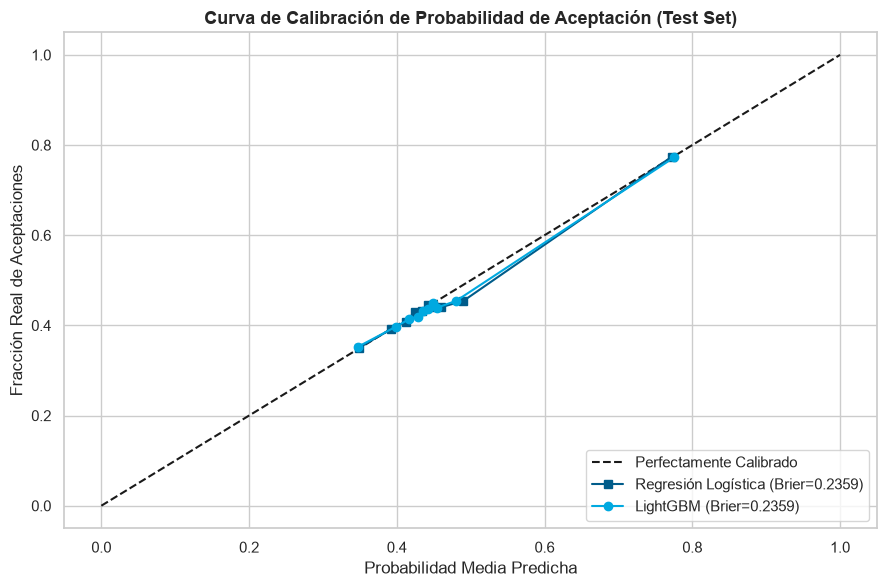

In [5]:
# Cálculo de curvas de calibración
prob_true_lr, prob_pred_lr = calibration_curve(y_test, p_lr_test, n_bins=10, strategy="quantile")
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, p_lgb_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(9, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectamente Calibrado")
plt.plot(prob_pred_lr, prob_true_lr, "s-", color="#005c8a", label=f"Regresión Logística (Brier={res_lr['brier_score']:.4f})")
plt.plot(prob_pred_lgb, prob_true_lgb, "o-", color="#00a9e0", label=f"LightGBM (Brier={res_lgb['brier_score']:.4f})")
plt.xlabel("Probabilidad Media Predicha")
plt.ylabel("Fracción Real de Aceptaciones")
plt.title("Curva de Calibración de Probabilidad de Aceptación (Test Set)", fontsize=13, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "curva_calibracion.png", dpi=300)
plt.show()

## 7. Construcción de Benchmarks y Estrategias de Decisión

Evaluamos las diferentes estrategias sobre el test set:
1. **`B0_azar`**: Asignación aleatoria uniforme de score.
2. **`B1_popularidad`**: Ranking por la tasa histórica global de aceptación de cada oferta.
3. **`B2_regla_negocio`**: Heurística comercial: Si el cliente es `elegible_mt`, prioriza ofertas MT; si no, prioriza upgrades y planes móviles.
4. **`B3_popularidad_celda`**: Tabla empírica de tasa de aceptación dentro de cada celda `(oferta_id, canal)`.
5. **`M1_probabilidad_pura`**: Score $= \hat{P}(\text{acepta})$.
6. **`M2_valor_esperado_EV`**: Score $= \hat{P}(\text{acepta}) \times \text{precio\_mensual}$.

In [6]:
df_test_eval = df_eval.iloc[test_idx].copy()
df_test_eval["p_lr"] = p_lr_test
df_test_eval["p_lgb"] = p_lgb_test
df_test_eval["precio"] = precios_test

# 1. B0 Azar
np.random.seed(RANDOM_STATE)
df_test_eval["score_b0_azar"] = np.random.uniform(0, 1, size=len(df_test_eval))

# 2. B1 Popularidad Global
tasa_global_oferta = df_eval.iloc[train_idx].groupby("oferta_id")["target"].mean().to_dict()
df_test_eval["score_b1_popularidad"] = df_test_eval["oferta_id"].map(tasa_global_oferta).fillna(df_eval["target"].mean())

# 3. B2 Regla de Negocio Heurística
def score_regla_negocio(row):
    if row["elegible_mt_cli"] and ("MT" in str(row["oferta_id"]) or row["cat_es_mt"]):
        return 0.90 + (row["cat_precio_mensual"] / 1000.0)
    elif "UPG" in str(row["oferta_id"]):
        return 0.60
    elif "MOV" in str(row["oferta_id"]):
        return 0.50
    elif "HOG" in str(row["oferta_id"]):
        return 0.40
    else:
        return 0.30

df_test_eval["score_b2_regla_negocio"] = df_test_eval.apply(score_regla_negocio, axis=1)

# 4. B3 Popularidad por Celda (oferta, canal)
df_train_sub = df_eval.iloc[train_idx]
tasa_celda = df_train_sub.groupby(["oferta_id", "canal"])["target"].mean().to_dict()
df_test_eval["score_b3_celda"] = df_test_eval.apply(
    lambda r: tasa_celda.get((r["oferta_id"], r["canal"]), tasa_global_oferta.get(r["oferta_id"], df_eval["target"].mean())), 
    axis=1
)

# 5. M1 Probabilidad Pura (LightGBM)
df_test_eval["score_m1_prob_pura"] = df_test_eval["p_lgb"]

# 6. M2 Valor Esperado (EV = p_lgb * precio)
df_test_eval["score_m2_ev_lgb"] = df_test_eval["p_lgb"] * df_test_eval["precio"]

# 7. M2-LR Valor Esperado (EV = p_lr * precio)
df_test_eval["score_m2_ev_lr"] = df_test_eval["p_lr"] * df_test_eval["precio"]

print("Scores calculados exitosamente para todas las estrategias.")

Scores calculados exitosamente para todas las estrategias.


## 8. Simulación Económica y Curvas de Ganancia por Presupuesto de Contactos

Simulamos la ejecución de campañas comerciales bajo presupuestos finitos de contactos ($K = 1,000, 5,000, 10,000, 20,000, 30,000$). En cada presupuesto, la política selecciona los $K$ contactos con mayor score predicho y medimos:
1. **PEN Capturado:** Ingreso mensual total generado por ofertas aceptadas reales (S/ / mes).
2. **Aceptaciones Reales:** Número total de ventas cerradas.
3. **Ticket Promedio por Aceptación:** Valor de cada cliente convertido.

In [7]:
estrategias = {
    "B0_Azar": "score_b0_azar",
    "B1_Popularidad_Global": "score_b1_popularidad",
    "B2_Regla_Negocio": "score_b2_regla_negocio",
    "B3_Popularidad_Celda": "score_b3_celda",
    "M1_Probabilidad_Pura": "score_m1_prob_pura",
    "M2_Valor_Esperado_EV (LGB)": "score_m2_ev_lgb",
    "M2_Valor_Esperado_EV (LR)": "score_m2_ev_lr"
}

presupuestos_k = [1000, 2500, 5000, 7500, 10000, 15000, 20000, 30000, len(df_test_eval)]
resultados_presupuesto = []

for nombre_est, col_score in estrategias.items():
    df_sorted = df_test_eval.sort_values(by=col_score, ascending=False).reset_index(drop=True)
    
    # Calcular acumulados
    df_sorted["ingreso_real"] = df_sorted["target"] * df_sorted["precio"]
    df_sorted["cum_pen"] = df_sorted["ingreso_real"].cumsum()
    df_sorted["cum_aceptaciones"] = df_sorted["target"].cumsum()
    
    for k in presupuestos_k:
        k_eval = min(k, len(df_sorted))
        pen_k = df_sorted.loc[k_eval - 1, "cum_pen"]
        acept_k = df_sorted.loc[k_eval - 1, "cum_aceptaciones"]
        ticket_prom = pen_k / acept_k if acept_k > 0 else 0
        tasa_conv = (acept_k / k_eval) * 100
        
        resultados_presupuesto.append({
            "estrategia": nombre_est,
            "presupuesto_k": k_eval,
            "pen_capturado_mensual": round(float(pen_k), 2),
            "aceptaciones_capturadas": int(acept_k),
            "tasa_conversion_pct": round(float(tasa_conv), 2),
            "ticket_promedio_pen": round(float(ticket_prom), 2)
        })

df_presupuesto = pd.DataFrame(resultados_presupuesto)

# Mostrar tabla pivote comparativa para K = 1,000, 5,000, 10,000, 20,000
piv_pen = df_presupuesto[df_presupuesto["presupuesto_k"].isin([1000, 5000, 10000, 20000])].pivot(
    index="estrategia", columns="presupuesto_k", values="pen_capturado_mensual"
)
piv_acept = df_presupuesto[df_presupuesto["presupuesto_k"].isin([1000, 5000, 10000, 20000])].pivot(
    index="estrategia", columns="presupuesto_k", values="aceptaciones_capturadas"
)

print("--- INGRESO MENSUAL CAPTURADO (PEN / mes) ---")
print(piv_pen.to_string())
print("\n--- ACEPTACIONES CAPTURADAS (Total Ventas) ---")
print(piv_acept.to_string())

--- INGRESO MENSUAL CAPTURADO (PEN / mes) ---
presupuesto_k                  1000      5000      10000      20000
estrategia                                                         
B0_Azar                      38882.3  201849.1  403967.2   807211.7
B1_Popularidad_Global       148501.8  683216.9  854626.0  1150001.6
B2_Regla_Negocio            176103.4  660665.5  795913.9  1070170.6
B3_Popularidad_Celda        128394.3  671558.3  825323.3  1084630.9
M1_Probabilidad_Pura        150709.5  661139.3  804794.8  1111896.1
M2_Valor_Esperado_EV (LGB)  181850.9  684016.4  972159.9  1364469.5
M2_Valor_Esperado_EV (LR)   183000.4  686095.1  972289.2  1365898.3

--- ACEPTACIONES CAPTURADAS (Total Ventas) ---
presupuesto_k               1000   5000   10000  20000
estrategia                                            
B0_Azar                       461   2300   4613   9151
B1_Popularidad_Global         782   3631   5762   9997
B2_Regla_Negocio              766   3618   5700   9841
B3_Popularidad_Celd

## 9. Visualización de Curvas de Captura de Valor Económico

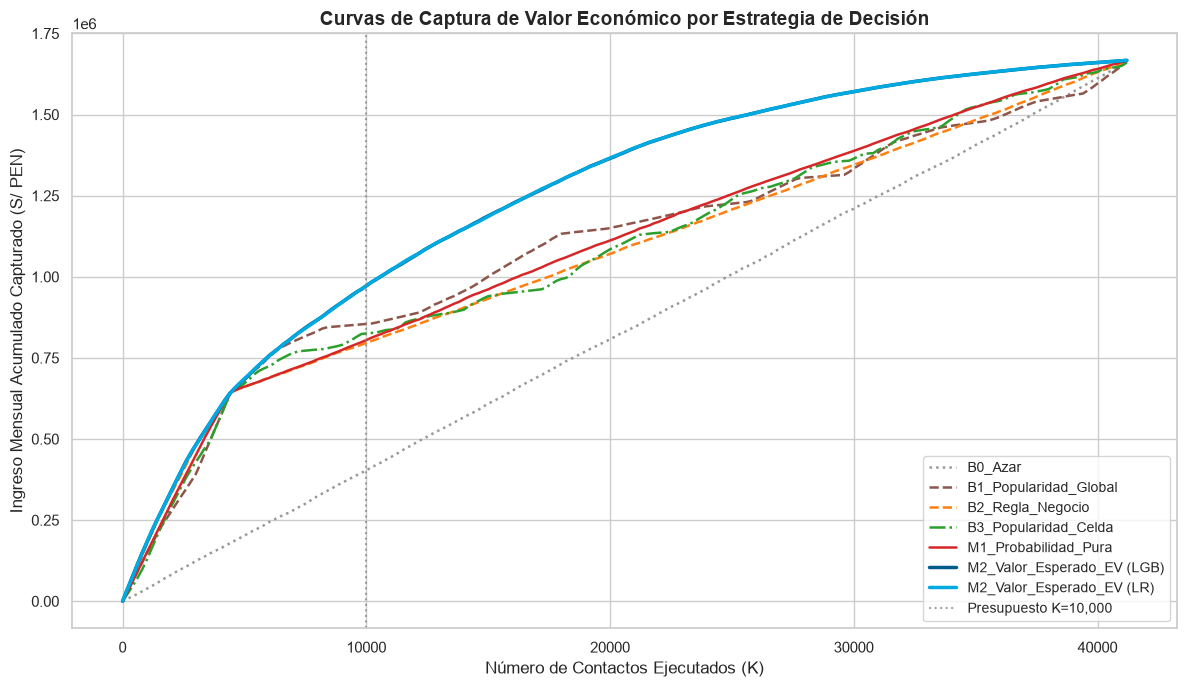

In [8]:
plt.figure(figsize=(12, 7))

colores = {
    "B0_Azar": "#999999",
    "B1_Popularidad_Global": "#8c564b",
    "B2_Regla_Negocio": "#ff7f0e",
    "B3_Popularidad_Celda": "#2ca02c",
    "M1_Probabilidad_Pura": "#d62728",
    "M2_Valor_Esperado_EV (LGB)": "#005c8a",
    "M2_Valor_Esperado_EV (LR)": "#00a9e0"
}

estilos = {
    "B0_Azar": ":",
    "B1_Popularidad_Global": "--",
    "B2_Regla_Negocio": "--",
    "B3_Popularidad_Celda": "-.",
    "M1_Probabilidad_Pura": "-",
    "M2_Valor_Esperado_EV (LGB)": "-",
    "M2_Valor_Esperado_EV (LR)": "-"
}

for nombre_est, col_score in estrategias.items():
    df_sorted = df_test_eval.sort_values(by=col_score, ascending=False).reset_index(drop=True)
    cum_pen = (df_sorted["target"] * df_sorted["precio"]).cumsum()
    k_range = np.arange(1, len(cum_pen) + 1)
    
    # Submuestrear para graficar ágilmente
    step = 200
    plt.plot(
        k_range[::step], 
        cum_pen.values[::step], 
        label=nombre_est, 
        color=colores.get(nombre_est, "#333333"),
        linestyle=estilos.get(nombre_est, "-"),
        linewidth=2.5 if "Valor_Esperado" in nombre_est else 1.8
    )

plt.axvline(x=10000, color="gray", linestyle=":", alpha=0.7, label="Presupuesto K=10,000")
plt.xlabel("Número de Contactos Ejecutados (K)", fontsize=12)
plt.ylabel("Ingreso Mensual Acumulado Capturado (S/ PEN)", fontsize=12)
plt.title("Curvas de Captura de Valor Económico por Estrategia de Decisión", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(DIR_SALIDA / "curvas_ganancia_economica.png", dpi=300)
plt.show()

## 10. Resumen Cuantitativo del Lift Económico (@ 10,000 contactos)

In [9]:
pen_10k_b2 = piv_pen.loc["B2_Regla_Negocio", 10000]
pen_10k_m1 = piv_pen.loc["M1_Probabilidad_Pura", 10000]
pen_10k_ev_lgb = piv_pen.loc["M2_Valor_Esperado_EV (LGB)", 10000]
pen_10k_ev_lr = piv_pen.loc["M2_Valor_Esperado_EV (LR)", 10000]

acept_10k_b2 = piv_acept.loc["B2_Regla_Negocio", 10000]
acept_10k_m1 = piv_acept.loc["M1_Probabilidad_Pura", 10000]
acept_10k_ev_lgb = piv_acept.loc["M2_Valor_Esperado_EV (LGB)", 10000]

lift_ev_vs_b2 = ((pen_10k_ev_lgb - pen_10k_b2) / pen_10k_b2) * 100
lift_ev_vs_m1 = ((pen_10k_ev_lgb - pen_10k_m1) / pen_10k_m1) * 100
lift_acept_vs_b2 = ((acept_10k_ev_lgb - acept_10k_b2) / acept_10k_b2) * 100

print(f"=== IMPACTO FINANCIERO A 10,000 CONTACTOS ===")
print(f"Ingreso B2 (Regla Negocio):         S/ {pen_10k_b2:,.2f}  ({acept_10k_b2:,} aceptaciones)")
print(f"Ingreso M1 (Probabilidad Pura):     S/ {pen_10k_m1:,.2f}  ({acept_10k_m1:,} aceptaciones)")
print(f"Ingreso M2 (Valor Esperado LGB):    S/ {pen_10k_ev_lgb:,.2f}  ({acept_10k_ev_lgb:,} aceptaciones)")
print(f"Ingreso M2 (Valor Esperado LR):     S/ {pen_10k_ev_lr:,.2f}")
print(f"-------------------------------------------------------------")
print(f"LIFT ECONÓMICO (EV vs Regla Negocio):  +{lift_ev_vs_b2:.2f}% de ingreso capturado")
print(f"LIFT ECONÓMICO (EV vs Prob Pura):      +{lift_ev_vs_m1:.2f}% de ingreso capturado")
print(f"LIFT EN VOLUMEN DE VENTAS (vs B2):     +{lift_acept_vs_b2:.2f}% de aceptaciones adicionales")

=== IMPACTO FINANCIERO A 10,000 CONTACTOS ===
Ingreso B2 (Regla Negocio):         S/ 795,913.90  (5,700 aceptaciones)
Ingreso M1 (Probabilidad Pura):     S/ 804,794.80  (5,846 aceptaciones)
Ingreso M2 (Valor Esperado LGB):    S/ 972,159.90  (5,801 aceptaciones)
Ingreso M2 (Valor Esperado LR):     S/ 972,289.20
-------------------------------------------------------------
LIFT ECONÓMICO (EV vs Regla Negocio):  +22.14% de ingreso capturado
LIFT ECONÓMICO (EV vs Prob Pura):      +20.80% de ingreso capturado
LIFT EN VOLUMEN DE VENTAS (vs B2):     +1.77% de aceptaciones adicionales


## 11. Persistencia de Artefactos y Métricas

In [10]:
# 1. Exportar comparativa completa
df_presupuesto.to_csv(DIR_SALIDA / "comparativa_estrategias_presupuesto.csv", index=False)
df_metricas_modelos.to_csv(DIR_SALIDA / "metricas_modelos_clasificacion.csv", index=False)

# 2. Exportar resumen ejecutivo JSON
resumen_ejecutivo = {
    "universo_evaluable": {
        "contactos_totales": int(n_contactos),
        "clientes_unicos": int(n_clientes_unicos),
        "tasa_aceptacion_base": round(float(tasa_aceptacion), 4),
        "rebates_excluidos": True
    },
    "metricas_clasificacion": df_metricas_modelos.to_dict(orient="records"),
    "impacto_economico_10k_contactos": {
        "pen_b2_regla_negocio": round(float(pen_10k_b2), 2),
        "pen_m1_prob_pura": round(float(pen_10k_m1), 2),
        "pen_m2_valor_esperado_lgb": round(float(pen_10k_ev_lgb), 2),
        "pen_m2_valor_esperado_lr": round(float(pen_10k_ev_lr), 2),
        "lift_ingreso_vs_reglas_pct": round(float(lift_ev_vs_b2), 2),
        "lift_ingreso_vs_prob_pura_pct": round(float(lift_ev_vs_m1), 2),
        "aceptaciones_10k_b2": int(acept_10k_b2),
        "aceptaciones_10k_m2_ev": int(acept_10k_ev_lgb),
        "lift_aceptaciones_vs_reglas_pct": round(float(lift_acept_vs_b2), 2)
    }
}

with open(DIR_SALIDA / "resumen_ejecutivo_valor_esperado.json", "w", encoding="utf-8") as f:
    json.dump(resumen_ejecutivo, f, indent=2, ensure_ascii=False)

print(f"Artefactos exportados exitosamente en: {DIR_SALIDA.resolve()}")

Artefactos exportados exitosamente en: D:\hacka_movistar\data\processed\modelo_valor_esperado
